In [ ]:
!pip install pandas scikit-learn fairlearn matplotlib

In [ ]:
import pandas as pd

df = pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
df = df.dropna()
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop("income_>50K", axis=1)
y = df["income_>50K"]

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv("adult.csv")

In [ ]:
df = df.dropna()
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop("income_>50K", axis=1)
y = df["income_>50K"]

In [ ]:
sensitive = X["gender_Male"]

In [ ]:
X_train, X_test, y_train, y_test, sens_train, sens_test = train_test_split(
    X, y, sensitive, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(
    max_iter=3000,
    solver="lbfgs",
    n_jobs=-1
)

In [ ]:
model = LogisticRegression(
    max_iter=3000,
    solver="lbfgs",
    n_jobs=-1
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=3000, n_jobs=-1)

In [ ]:
preds = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, preds)
print("Accuracy:", accuracy)

Accuracy: 0.8573037158358071


In [ ]:
from fairlearn.metrics import MetricFrame, selection_rate

mf = MetricFrame(
    metrics=selection_rate,
    y_true=y_test,
    y_pred=preds,
    sensitive_features=sens_test
)

print(mf.by_group)

gender_Male
False    0.072744
True     0.253571
Name: selection_rate, dtype: float64


In [ ]:
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from sklearn.linear_model import LogisticRegression

mitigator = ExponentiatedGradient(
    LogisticRegression(max_iter=3000),
    constraints=DemographicParity()
)

mitigator.fit(X_train, y_train, sensitive_features=sens_train)

mitigated_preds = mitigator.predict(X_test)

In [ ]:
from fairlearn.metrics import MetricFrame, selection_rate

mf_mitigated = MetricFrame(
    metrics=selection_rate,
    y_true=y_test,
    y_pred=mitigated_preds,
    sensitive_features=sens_test
)

print(mf_mitigated.by_group)

gender_Male
False    0.155617
True     0.176624
Name: selection_rate, dtype: float64


In [ ]:
from sklearn.metrics import accuracy_score

print("Before mitigation:", accuracy_score(y_test, preds))
print("After mitigation:", accuracy_score(y_test, mitigated_preds))

Before mitigation: 0.8573037158358071
After mitigation: 0.8400040945849114


In [ ]:
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate

# Compute both selection rate and Equal Opportunity (TPR)
mf = MetricFrame(
    metrics={
        "selection_rate": selection_rate,
        "tpr": true_positive_rate
    },
    y_true=y_test,
    y_pred=preds,  # use mitigated_preds if after mitigation
    sensitive_features=sens_test
)

print(mf.by_group)

             selection_rate       tpr
gender_Male                          
False              0.072744  0.540541
True               0.253571  0.619315


In [26]:
mf_before = MetricFrame(
    metrics={
        "selection_rate": selection_rate,
        "tpr": true_positive_rate
    },
    y_true=y_test,
    y_pred=preds,
    sensitive_features=sens_test
)

print("Before Mitigation:\n", mf_before.by_group)

Before Mitigation:
              selection_rate       tpr
gender_Male                          
False              0.072744  0.540541
True               0.253571  0.619315


In [27]:
mf_after = MetricFrame(
    metrics={
        "selection_rate": selection_rate,
        "tpr": true_positive_rate
    },
    y_true=y_test,
    y_pred=mitigated_preds,
    sensitive_features=sens_test
)

print("After Mitigation:\n", mf_after.by_group)

After Mitigation:
              selection_rate       tpr
gender_Male                          
False              0.155617  0.795796
True               0.176624  0.473684


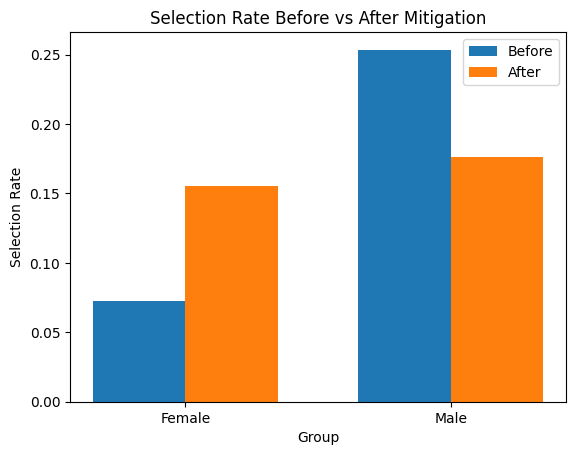

In [28]:
import matplotlib.pyplot as plt
import numpy as np

groups = ["Female", "Male"]

# Selection rates
before_sr = mf_before.by_group["selection_rate"].values
after_sr = mf_after.by_group["selection_rate"].values

x = np.arange(len(groups))
width = 0.35

plt.figure()
plt.bar(x - width/2, before_sr, width, label="Before")
plt.bar(x + width/2, after_sr, width, label="After")

plt.xticks(x, groups)
plt.title("Selection Rate Before vs After Mitigation")
plt.xlabel("Group")
plt.ylabel("Selection Rate")
plt.legend()

plt.show()